# Kiểm tra tuân thủ đội mũ bảo vệ với YOLOv10

## I.Giới thiệu

**Object Detection (Tạm dịch: Phát hiện đối tượng)** là một bài toán cổ điển thuộc lĩnh vực Computer Vision. Mục tiêu của bài toán này là tự động xác định vị trí của các đối tượng trong một tấm ảnh. Đây là một trong những bài toán quan trọng và phức tạp trong Computer Vision, với ứng dụng rộng rãi từ nhận diện khuôn mặt, nhận dạng biển số xe, đến theo dõi đối tượng trong video và tự động lái xe.

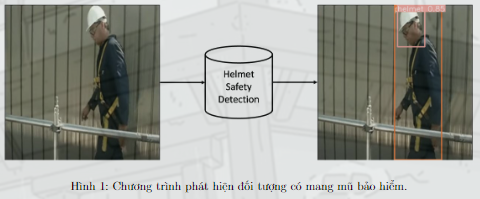

Trong project này, chúng ta sẽ xây dựng một chương trình phát hiện các nhân viên có đeo mũ bảo vệ trong công trường hay không? Mô hình mà chúng ta sử dụng sẽ là mô hình YOLOv10.

Theo đó, Input và Output của chương trình là:
- Input: Một tấm ảnh.
- Output: Tọa độ (bounding box) của các nhân viên và phần mũ bảo hiểm.

Tổng quan, các bước thực hiện trong project của chúng để hoàn thiện hệ thống Helmet Safety Detection bao gồm:

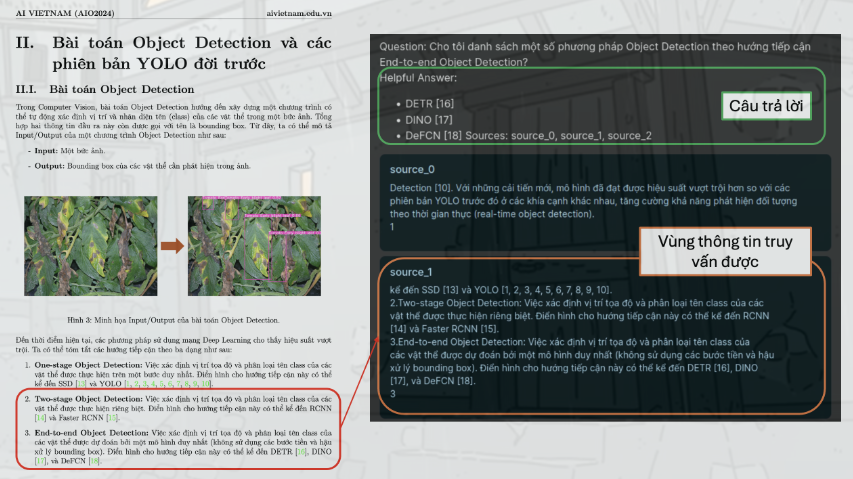

Luồng xử lý (pipeline) của chương trình Helmet Safety Detection mà chúng ta sẽ xây dựng có dạng như sau:

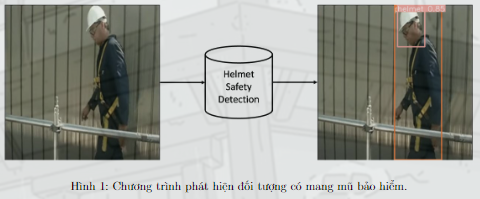


## II. Cài đặt và sử dụng pre-trained model
Trong phần này, chúng ta sẽ tìm hiểu cách sử dụng YOLOv10 bao gồm việc sử dụng pre-trained model và huấn luyện (fine-tuning) YOLOv10 trên bộ dữ liệu Helmet Safety Detection.

Một cách nhanh chóng để sử dụng được YOLOv10 đó là sử dụng pre-trained model (mô hình đã được huấn luyện sẵn trên bộ dữ liệu COCO - một bộ dữ liệu rất lớn)

### II.I. Chuẩn bị môi trường lập trình

#### 1. Tải mã nguồn YOLOv10 từ GitHub

In [5]:
!git clone https://github.com/THU-MIG/yolov10.git

fatal: destination path 'yolov10' already exists and is not an empty directory.


#### 2. Cài đặt các thư viện cần thiết

In [6]:
%cd yolov10
%pip install -q -r requirements.txt
%pip install -e .

c:\Users\xps15\Desktop\AIO24\AIO24-Exercise\Module01\Week_4\yolov10
Note: you may need to restart the kernel to use updated packages.
Obtaining file:///C:/Users/xps15/Desktop/AIO24/AIO24-Exercise/Module01/Week_4/yolov10
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
    Preparing wheel metadata: started
    Preparing wheel metadata: finished with status 'done'
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.1.34
    Uninstalling ultralytics-8.1.34:
      Successfully uninstalled ultralytics-8.1.34
  Running setup.py develop for ultralytics
Note: you may need to restart the kernel to use updated packages.


#### 3. Tải trọng số của pre-trained models

In [55]:
import requests

url = "https://github.com/THU-MIG/yolov10/releases/download/v1.1/yolov10n.pt"
response = requests.get(url)

with open("yolov10n.pt", "wb") as f:
    f.write(response.content)

In [57]:
from yolov10.ultralytics import YOLOv10
import streamlit as st
from PIL import Image
import cv2

TRAINED_MODEL_PATH = 'runs/detect/train/weights/best.pt'
model = YOLOv10(TRAINED_MODEL_PATH)


def main():
    st.title('Safety Helmet Checking')
    file = st.file_uploader('Upload Image ', type=['jpg', 'png', 'jpeg'])
    if file is not None:
        st.image(file, caption="Uploaded Image")
        image = Image.open(file)
        processed_image = model.predict(source=image, conf=0.3)
        print(type(processed_image))
        cv2.imshow(mat=processed_image)

main()


### II.III. Huấn luyện YOLOv10 trên tập dữ liệu mới

#### 1. Tải bộ dữ liệu

In [8]:
# https://drive.google.com/file/d/1twdtZEfcw4ghSZIiPDypJurZnNXzMO7R/view?usp=sharing
!gdown 1twdtZEfcw4ghSZIiPDypJurZnNXzMO7R

Downloading...
From (original): https://drive.google.com/uc?id=1twdtZEfcw4ghSZIiPDypJurZnNXzMO7R
From (redirected): https://drive.google.com/uc?id=1twdtZEfcw4ghSZIiPDypJurZnNXzMO7R&confirm=t&uuid=fbf560cb-12d7-4e05-9071-f7b0d63b248d
To: c:\Users\xps15\Desktop\AIO24\AIO24-Exercise\Module01\Week_4\yolov10\Safety_Helmet_Dataset.zip

  0%|          | 0.00/33.7M [00:00<?, ?B/s]
  2%|▏         | 524k/33.7M [00:00<00:31, 1.06MB/s]
  3%|▎         | 1.05M/33.7M [00:00<00:22, 1.48MB/s]
  5%|▍         | 1.57M/33.7M [00:01<00:20, 1.60MB/s]
  6%|▌         | 2.10M/33.7M [00:01<00:18, 1.74MB/s]
  8%|▊         | 2.62M/33.7M [00:01<00:17, 1.80MB/s]
  9%|▉         | 3.15M/33.7M [00:01<00:17, 1.73MB/s]
 11%|█         | 3.67M/33.7M [00:02<00:16, 1.79MB/s]
 12%|█▏        | 4.19M/33.7M [00:02<00:15, 1.87MB/s]
 14%|█▍        | 4.72M/33.7M [00:02<00:14, 2.04MB/s]
 16%|█▌        | 5.24M/33.7M [00:02<00:13, 2.04MB/s]
 17%|█▋        | 5.77M/33.7M [00:03<00:12, 2.16MB/s]
 19%|█▊        | 6.29M/33.7M [00:03<00:13,

#### 2. Giải nén bộ dữ liệu vào folder datasets

In [8]:
!mkdir safety_helmet_dataset

In [18]:
import zipfile
import os

zip_file = 'Safety_Helmet_Dataset.zip'
extract_dir = 'safety_helmet_dataset'

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

#### 3. Khởi tạo mô hình YOLOv10

In [9]:
pwd

'c:\\Users\\xps15\\Desktop\\AIO24\\AIO24-Exercise\\Module01\\Week_4\\yolov10'

In [10]:
from ultralytics import YOLOv10

MODEL_PATH = 'yolov10n.pt'
model = YOLOv10(MODEL_PATH)

In [13]:
model.info()

YOLOv10n summary: 385 layers, 2775520 parameters, 2775504 gradients, 8.7 GFLOPs


(385, 2775520, 2775504, 8.741504)

In [14]:
YAML_PATH = '../safety_helmet_dataset/data.yaml'
EPOCHS = 50
IMG_SIZE = 640
BATCH_SIZE = 128 #256

#### **4. Training**
**trainning in colab**

## **8. Evaluate model**

In [15]:
TRAINED_MODEL_PATH = 'runs/detect/train/weights/best.pt'
model = YOLOv10(TRAINED_MODEL_PATH)

model.val(data=YAML_PATH,
          imgsz=IMG_SIZE,
          split='test')

Ultralytics YOLOv8.1.34 🚀 Python-3.10.4 torch-2.0.1+cpu CPU (Intel Core(TM) i7-7700HQ 2.80GHz)
YOLOv10n summary (fused): 285 layers, 2695586 parameters, 0 gradients, 8.2 GFLOPs


val: Scanning C:\Users\xps15\Desktop\AIO24\AIO24-Exercise\Module01\Week_4\safety_helmet_dataset\test\labels.cache... 109 images, 0 backgrounds, 0 corrupt: 100%|██████████| 109/109 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):   0%|          | 0/7 [00:02<?, ?it/s]


KeyboardInterrupt: 

## **9. Run prediction with an image**

In [16]:
# https://github.com/googlecolab/colabtools/issues/3409
import locale
locale.getpreferredencoding = lambda: "UTF-8"

In [50]:
import cv2
TRAINED_MODEL_PATH = 'runs/detect/train/weights/best.pt'
model = YOLOv10(TRAINED_MODEL_PATH)

IMAGE_URL = 'https://ips-dc.org/wp-content/uploads/2022/05/Black-Workers-Need-a-Bill-of-Rights.jpeg'
CONF_THRESHOLD = 0.3
results = model.predict(source=IMAGE_URL,
                       imgsz=IMG_SIZE,
                       conf=CONF_THRESHOLD)[0]


Found https://ips-dc.org/wp-content/uploads/2022/05/Black-Workers-Need-a-Bill-of-Rights.jpeg locally at Black-Workers-Need-a-Bill-of-Rights.jpeg
image 1/1 c:\Users\xps15\Desktop\AIO24\AIO24-Exercise\Module01\Week_4\yolov10\Black-Workers-Need-a-Bill-of-Rights.jpeg: 448x640 1 helmet, 213.4ms
Speed: 4.0ms preprocess, 213.4ms inference, 1.0ms postprocess per image at shape (1, 3, 448, 640)


import mathplotlib as plt

In [47]:
import matplotlib as plt


In [51]:
results.show()


### 2. Object Detection
Object Detection là ứng dụng quan trọng điển hình của xử lý hình ảnh, với mục tiêu phát hiện các khung hình chứa các đối tượng trong ảnh. Ví dụ minh hoạ về ứng dụng như hình sau:

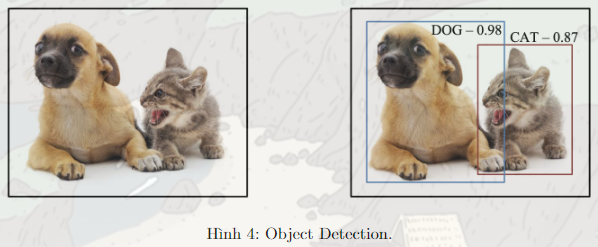

Trong phần này chúng ta sẽ xây dựng ứng dụng cho người dùng tải lên ảnh đầu vào, sử dụng mô hình DNN từ thư viện opencv (Vì phần project này tập trung vào thư viện streamlit vì vậy nên chúng ta sẽ không đi sâu vào mô hình DNN của thư viện opencv). 

Chúng ta xây dựng 2 hàm: 
- 1 hàm để đẩy ảnh đầu vào vào mô hình DNN để tìm được các bounding box phù hợp
- 1 hàm để lọc những bounding box có độ tin cậy thấp và trả về kết quả là các vị trí toạ độ của bounding box đó. 

Các cài đặt cho mô hình được thiết lập trong 2 file model và prototxt có thể được tải về **[tại đây](https://drive.google.com/file/d/1h61ZdkuX0i2Z70tkGx3UyTMXsl4EELw5/view "vocabulary").**

Mã nguồn ví dụ như sau:

In [52]:
TRAINED_MODEL_PATH = 'runs/detect/train/weights/best.pt'
def annotate_image(image, CONF_THRESHOLD = 0.3):
    
    model = YOLOv10(TRAINED_MODEL_PATH)
    image = model.predict(source=IMAGE_URL,
                        # imgsz=640,
                        conf=CONF_THRESHOLD)
    return image[0]

Giao diện ứng dụng được mô tả như hình sau:
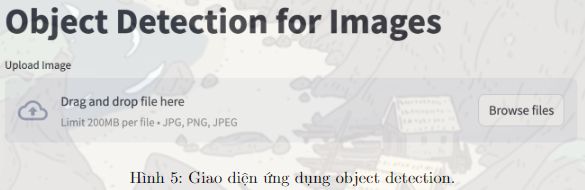

In [68]:
image = Image.open('Black-Workers-Need-a-Bill-of-Rights.jpeg')
processed_image = model.predict(source=image, conf=0.3)[0]


Found https://ips-dc.org/wp-content/uploads/2022/05/Black-Workers-Need-a-Bill-of-Rights.jpeg locally at Black-Workers-Need-a-Bill-of-Rights.jpeg
image 1/1 c:\Users\xps15\Desktop\AIO24\AIO24-Exercise\Module01\Week_4\yolov10\Black-Workers-Need-a-Bill-of-Rights.jpeg: 224x320 1 helmet, 60.8ms
Speed: 1.0ms preprocess, 60.8ms inference, 1.0ms postprocess per image at shape (1, 3, 224, 320)


In [75]:
cv2.(processed_image)

AttributeError: module 'cv2' has no attribute 'show'

Sau đó, tất cả code sẽ được để trong file: __’object_detection.py’__. Cuối cùng chúng ta chạy lệnh __’streamlit run object_detection.py’__ để thử nghiệm và thu được kết quả như sau:
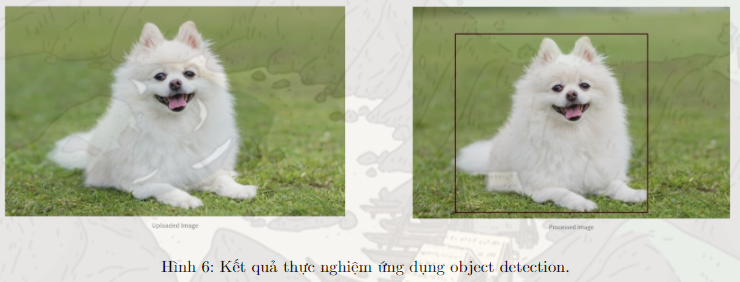

### 3. Chatbot
Chatbot là ứng dụng được chú ý phát triển mạnh những năm gần đây, các ứng dụng chatbot chủ yếu tập trung vào các mô hình ngôn ngữ lớn có thể tương tác tốt với các yêu cầu của người dùng.

Ví dụ về chatbot được mô tả trong hình sau:

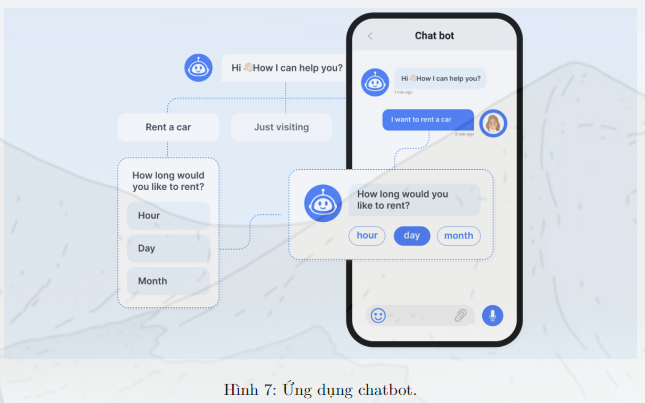

Trong phần này, chúng ta xây dựng ứng dụng chatbot đơn giản dựa trên thư viện __hugchat__ và __streamlit__. Đầu tiên chúng ta cần có tài khoảng **hugging face** để có quyền truy cập __hugchat__. Sau
đó truy cập vào **[trang](https://huggingface.co/chat/ "hugchat").** sau đây để gửi yêu cầu truy cập __hugchat__.

Sau khi được chấp nhận quyền truy cập, chúng ta xây dựng giao diện ứng dụng được mô tả như sau:

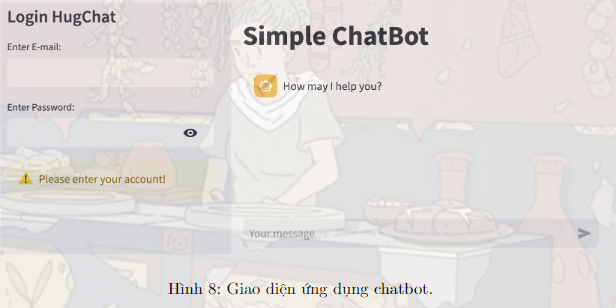

Giao diện có bố cục gồm 2 phần:


- **Phần bên trái**: Chứa thông tin nhập vào tài khoản và mật khẩu huggingface, được sử dụng để có quyền truy cập vào hugchat

In [8]:
import streamlit as st
from hugchat import hugchat
from hugchat.login import Login

# App title
st.title('Simple ChatBot ')

# Hugging Face Credentials
with st.sidebar:
    st.title('Login HugChat ')
    hf_email = st.text_input('Enter E-mail:')
    hf_pass = st.text_input('Enter Password:')#, type='password')
    if not (hf_email and hf_pass):
        st.warning('Please enter your account!')
    else:
        st.success('Proceed to entering your prompt message!')

- Phần bên phải (phần trung tâm): Chứa khu vực nhập vào văn bản và trả về phản hồi từ chatbot.

In [9]:
# Store LLM generated responses
if "messages" not in st.session_state.keys():
    st.session_state.messages = [{"role": "assistant", "content": "How may I help you?"}]

# Display chat messages
for message in st.session_state.messages:
    with st.chat_message(message["role"]):
        st.write(message["content"])

Tương ứng với mỗi request gửi đến chatbot, mô hình sẽ đăng nhập vào hugchat và đưa ra phản hồi tương ứng:

In [12]:
# Function for generating LLM response
def generate_response(prompt_input, email, passwd):
    # Hugging Face Login
    sign = Login(email, passwd)
    cookies = sign.login()
    # Create ChatBot
    chatbot = hugchat.ChatBot(cookies=cookies.get_dict())
    return chatbot.chat(prompt_input)

# User -provided prompt
if prompt := st.chat_input(disabled=not(hf_email and hf_pass)):
    st.session_state.messages.append({"role": "user", "content": prompt })
    with st.chat_message("user"):
        st.write(prompt)

# Generate a new response if last message is not from assistant
if st.session_state.messages [-1]["role"] != "assistant":
    with st.chat_message("assistant"):
        with st.spinner("Thinking ..."):
            response = generate_response(prompt , hf_email , hf_pass)
            st.write(response)

message = {"role": "assistant", "content": response}
st.session_state.messages.append(message)

Sau khi hoàn thiện code vào file __’chatbot.py’__, chúng ta chạy lệnh: __’streamlit run chatbot.py’__ và thử nghiệm thu được kết quả như sau:

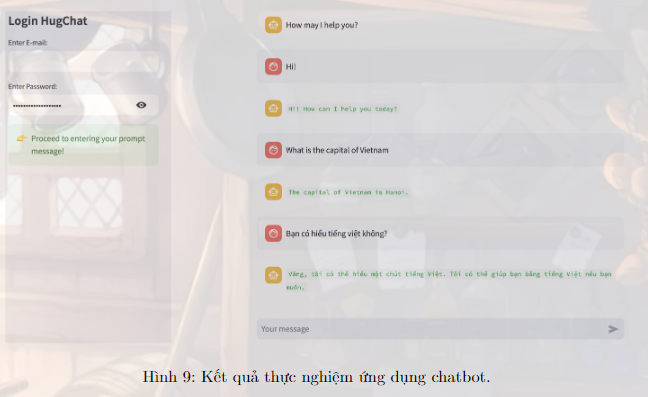

## II. Câu hỏi trắc nghiệm

### Câu hỏi 1: Hàm nào sau đây được sử dụng để hiển thị chuỗi văn bản trong streamlit.
__a) st.text(...)__

b) st.image(...)

c) st.selectbox(...)

d) st.slider(...)

### Câu hỏi 2: Đoạn code nào sau đây thể hiện đúng để hiển thị cho giao diện sau:
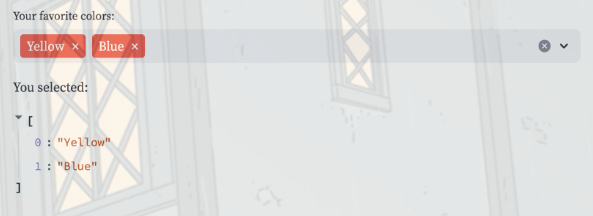

In [13]:
# a)
options = st.multiselect("Your favorite colors:")
st.write("You selected:", options)

# b)
options = st.multiselect("Your favorite colors:", ["Green", "Yellow", "Red", "Blue"], ["Yellow", "Red"])

## C) ##
options = st.multiselect("Your favorite colors:", ["Green", "Yellow", "Red", "Blue"], ["Yellow", "Red"])
st.write("You selected:", options)

# d)
options = st.selectbox("Your favorite colors:", ["Green", "Yellow", "Red", "Blue"], ["Yellow", "Red"])
st.write("You selected:", options)

### Câu hỏi 3: Hàm nào sau đây trong streamlit sử dụng để người dùng nhập văn bản trên giao diện.
a) st.text(...)

b) st.multibox(...)

c) st.audio(...)

__d) st.text_input(...)__

### Câu hỏi 4: Khai báo nào sau đây là **sai**.
a) st.image(image_path, caption=’A cat’, width=100, channels=’RGB’)

b) st.image(image_path, caption=’A cat’, width=None, channels=’BGR’)

__c) st.image(image_path, caption=’A cat’, width=’RGB’, channels=’BGR’)__

d) st.image(image_path, caption=’A cat’, width=None, channels=’RGB’)

### Câu hỏi 5: Tính khoảng cách chỉnh sửa levenshtein của 2 từ sau: "elmets" và "elements".
__a) 2__

b) 3

c) 4

d) 5


In [17]:
levenshtein_distance("elmets", "elements")

2

### Câu hỏi 6: Hàm st.session_state trong streamlit được sử dụng để làm gì.
a) Hiển thị chuỗi văn bản

b) Hiển thị hình ảnh

c) Lưu hình ảnh

__d) Chia sẻ các biến tỏng mỗi phiên truy cập của người dùng__

### Câu hỏi 7: Đoạn code nào thể hiện đúng cho giao diện sau đây.
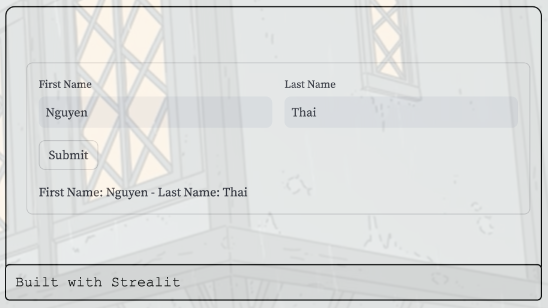

In [19]:
# a)
col1 , col2 = st.columns (2)
f_name = col1.text_input('First Name')
l_name = col2.text_input('Last Name')

# b)
with st.form("my_form"):
    col1 , col2 = st.columns(2)
    f_name = col1.text_input('First Name')
    l_name = col2.text_input('Last Name')

# c)
with st.form("my_form"):
    col1 , col2 = st.columns(2)
    f_name = col1.text_input('First Name')
    l_name = col2.text_input('Last Name')
    submitted = st.form_submit_button("Submit")

## D) ##
with st.form("my_form"):
    col1 , col2 = st.columns(2)
    f_name = col1.text_input('First Name')
    l_name = col2.text_input('Last Name')
    submitted = st.form_submit_button("Submit")
    if submitted:
        st.write("First Name: ", f_name ," - Last Name:", l_name)

### Câu hỏi 8: Hàm nào sau đây cho phép người dùng tải lên nhiều file.


In [ ]:
## A) ##
uploaded_files = st.file_uploader("Choose files", accept_multiple_files=True)

# b) 
uploaded_files = st.multifile_uploader("Choose files", accept_multiple_files=True)

# c) 
uploaded_files = st.file_uploader("Choose files")

# d) 
uploaded_files = st.multifile_uploader("Choose files")

### Câu hỏi 9: Hàm nào sau đây không được sử dụng để hiển thị code trong streamlit?
a) st.code(...)

b) st.echo(...)

c) st.markdown(...)

__d) st.slider(...)__

### Câu hỏi 10: Dung lượng mặc định tối đa mỗi file được tải lên trong streamlit là bao nhiêu.
a) 100 MB

__b) 200 MB__

c) 300 MB

d) 400 MB